In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

In [ ]:
#entonro
env = gym.make("CartPole-v1")
print("==== ENTORNO CARTPOLE-V1 ====")
print(f"Espacio de observacion:\n{env.observation_space}")
print(f"\t- Tipo: {env.observation_space.dtype}")
print(f"\t- Dimension: {env.observation_space.shape}")
print(f"\t- Rangos: {env.observation_space.low} - {env.observation_space.high}")

print(f"Espacio de accion:\n{env.action_space}")
print(f"\t- Tipo: {env.action_space.dtype}")
print(f"\t- Dimension: {env.action_space.shape}")
print(f"\t- No. acciones: {env.action_space.n}")

==== ENTORNO CARTPOLE-V1 ====
Espacio de observacion:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
	- Tipo: float32
	- Dimension: (4,)
	- Rangos: [-4.8               -inf -0.41887903        -inf] - [4.8               inf 0.41887903        inf]
Espacio de accion:
Discrete(2)
	- Tipo: int64
	- Dimension: ()
	- No. acciones: 2


In [ ]:
#agente aleatorio
print("==== AGENTE ALEATORIO ====")
def agente_random(env_name, num_eps):
  env = gym.make(env_name)
  rewards_ep = []
  steps_ep = []

  for episode in range(num_eps):
    obs, info = env.reset()
    done = False
    trunc = False
    total_reward = 0
    steps = 0

    while not done and not trunc:
        #random act
        accion = env.action_space.sample()
        obs, reward, done, trunc, info = env.step(accion)

        total_reward+=reward
        steps += 1

    rewards_ep.append(total_reward)
    steps_ep.append(steps)

    print(f"Episodio {episode+1}: Pasos={steps}, Recompensa Total={total_reward}")

  env.close()
  return rewards_ep, steps_ep

rewards_cart, steps_cart = agente_random("CartPole-v1", num_eps=20)

==== AGENTE ALEATORIO ====
Episodio 1: Pasos=14, Recompensa Total=14.0
Episodio 2: Pasos=14, Recompensa Total=14.0
Episodio 3: Pasos=24, Recompensa Total=24.0
Episodio 4: Pasos=17, Recompensa Total=17.0
Episodio 5: Pasos=62, Recompensa Total=62.0
Episodio 6: Pasos=27, Recompensa Total=27.0
Episodio 7: Pasos=20, Recompensa Total=20.0
Episodio 8: Pasos=22, Recompensa Total=22.0
Episodio 9: Pasos=51, Recompensa Total=51.0
Episodio 10: Pasos=21, Recompensa Total=21.0
Episodio 11: Pasos=30, Recompensa Total=30.0
Episodio 12: Pasos=44, Recompensa Total=44.0
Episodio 13: Pasos=26, Recompensa Total=26.0
Episodio 14: Pasos=11, Recompensa Total=11.0
Episodio 15: Pasos=11, Recompensa Total=11.0
Episodio 16: Pasos=16, Recompensa Total=16.0
Episodio 17: Pasos=20, Recompensa Total=20.0
Episodio 18: Pasos=35, Recompensa Total=35.0
Episodio 19: Pasos=34, Recompensa Total=34.0
Episodio 20: Pasos=24, Recompensa Total=24.0


/tmp/ipykernel_8584/225882873.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


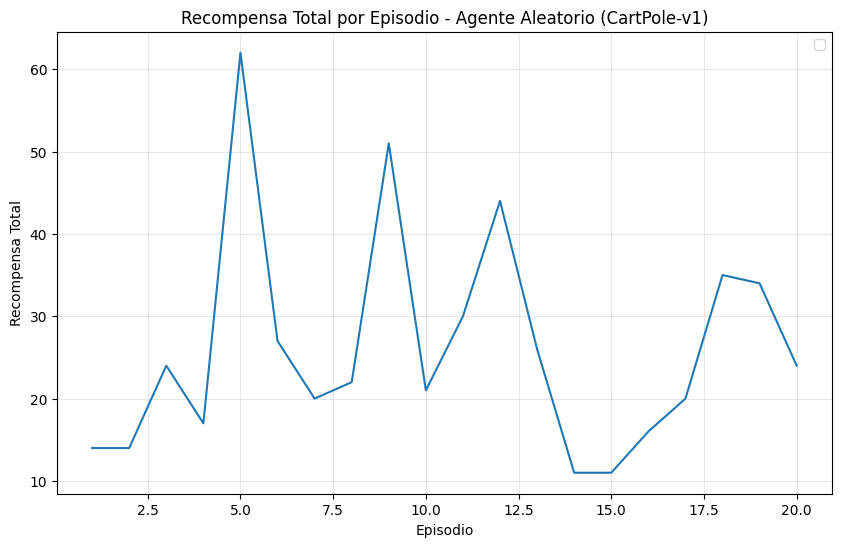

In [ ]:
#graficas
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rewards_cart)+1), rewards_cart, markersize=8)
plt.xlabel('Episodio')
plt.ylabel('Recompensa Total')
plt.title('Recompensa Total por Episodio - Agente Aleatorio (CartPole-v1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
#Frozen lake
print("==== SEGUNDO ENTORNO ====")
print("--- Env: FrozenLakev-1 ---")
env_2 = gym.make("FrozenLake-v1", desc=None, map_name="4x4", is_slippery=True)

print(f"Espacio de observacion:\n{env_2.observation_space}")
print(f"\t- Tipo: {env_2.observation_space.dtype}")
print(f"\t- No. estados: {env_2.observation_space.n}")

print(f"Espacio de accion:\n{env_2.action_space}")
print(f"\t- Tipo: {env_2.action_space.dtype}")
print(f"\t- No. acciones: {env_2.action_space.n}\n")

print("- Slippery:")
rewards_frozen, steps_frozen = agente_random('FrozenLake-v1', num_eps=20)

env_3 = gym.make("FrozenLake-v1", desc=None, map_name="4x4", is_slippery=False)
print("- No Slippery:")
rewards_frozen, steps_frozen = agente_random('FrozenLake-v1', num_eps=20)

==== SEGUNDO ENTORNO ====
--- Env: FrozenLakev-1 ---
Espacio de observacion:
Discrete(16)
	- Tipo: int64
	- No. estados: 16
Espacio de accion:
Discrete(4)
	- Tipo: int64
	- No. acciones: 4

- Slippery:
Episodio 1: Pasos=5, Recompensa Total=0
Episodio 2: Pasos=4, Recompensa Total=0
Episodio 3: Pasos=3, Recompensa Total=0
Episodio 4: Pasos=14, Recompensa Total=0
Episodio 5: Pasos=4, Recompensa Total=0
Episodio 6: Pasos=4, Recompensa Total=0
Episodio 7: Pasos=6, Recompensa Total=0
Episodio 8: Pasos=9, Recompensa Total=0
Episodio 9: Pasos=3, Recompensa Total=0
Episodio 10: Pasos=13, Recompensa Total=0
Episodio 11: Pasos=12, Recompensa Total=0
Episodio 12: Pasos=11, Recompensa Total=0
Episodio 13: Pasos=3, Recompensa Total=0
Episodio 14: Pasos=8, Recompensa Total=0
Episodio 15: Pasos=10, Recompensa Total=0
Episodio 16: Pasos=6, Recompensa Total=0
Episodio 17: Pasos=3, Recompensa Total=0
Episodio 18: Pasos=5, Recompensa Total=0
Episodio 19: Pasos=10, Recompensa Total=0
Episodio 20: Pasos=9, 

No lo resuelve, esto debido a que se necesita una sequencia especifica de pasos para "ganar", la cosa es que estamos usado un modelo aleatorio en un problema de navegación. Estos problemas requieren un plan consiso para no caer en los hoyos y llegar a su destino. Además de que a diferencia de CartPole, el fedback de FrozenLake se obtiene al final.


In [ ]:
#Comparaciones
print("==== COMPARACIONES ENTORNOS ====")
print("--- CartPole ---")
print(f"- Recompensa (prom.): {np.mean(rewards_cart)}")
print(f"- Pasos (prom.): {np.mean(steps_cart)}")

print("--- FrozenLake ---")
print(f"- Recompensa (prom.): {np.mean(rewards_frozen)}")
print(f"- Pasos (prom.): {np.mean(steps_frozen)}")

==== COMPARACIONES ENTORNOS ====
--- CartPole ---
- Recompensa (prom.): 26.15
- Pasos (prom.): 26.15
--- FrozenLake ---
- Recompensa (prom.): 0.0
- Pasos (prom.): 7.45


In [ ]:
#politica
print("==== POLITICA SIMPLE ====")
def politica_simple_cartpole(obs):
    """
    Politica simple: angulo poste, si el angulos es + se emuja a derecha (1), si es - a la izquierda (0)
    """
    angulo = obs[2]
    return 1 if angulo > 0 else 0

def politica(env_name, politica, num_episodios=5, render=False):
    env = gym.make(env_name)
    rewards_pol = []
    steps_pol = []

    for episode in range(num_episodios):
        obs, info = env.reset()
        done = False
        trunc = False
        total_reward = 0
        step_count = 0

        while not done and not trunc:
            if render:
                env.render()

            accion = politica(obs)
            obs, reward, done, trunc, info = env.step(accion)
            total_reward += reward
            step_count += 1

        rewards_pol.append(total_reward)
        steps_pol.append(step_count)
        print(f"Episodio {episode+1}: Pasos={step_count}, Recompensa={total_reward}")

    env.close()
    return rewards_pol, steps_pol

print("\nPolitica Simple (angulo poste):")
recompensas_politica, pasos_politica = politica('CartPole-v1', politica_simple_cartpole, num_episodios=5)

print("\nAgente Aleatorio (5 episodios):")
rewards_aleatorio_5, steps_aleatorio_5 = agente_random('CartPole-v1', num_eps=5)

==== POLITICA SIMPLE ====

Politica Simple (angulo poste):
Episodio 1: Pasos=51, Recompensa=51.0
Episodio 2: Pasos=36, Recompensa=36.0
Episodio 3: Pasos=25, Recompensa=25.0
Episodio 4: Pasos=35, Recompensa=35.0
Episodio 5: Pasos=35, Recompensa=35.0

Agente Aleatorio (5 episodios):
Episodio 1: Pasos=13, Recompensa Total=13.0
Episodio 2: Pasos=16, Recompensa Total=16.0
Episodio 3: Pasos=18, Recompensa Total=18.0
Episodio 4: Pasos=50, Recompensa Total=50.0
Episodio 5: Pasos=16, Recompensa Total=16.0



Metrica                   Politica (Angulo)         Agente Aleatorio    
----------------------------------------------------------------------
Recompensa promedio       36.40                     22.60                    
Desviacion estandar       8.33                      13.79                    
Pasos promedio            36.40                     22.60                    
Recompensa max            51.0                      50.0                     
Recompensa min            25.0                      13.0                     

  - Mejora Politica vs Agente: 61.06%
  (Promedio: 36.4 vs 22.6 pasos)


/tmp/ipykernel_8584/3739071472.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(datos, labels=['Politica', 'Agente Aleatorio'], patch_artist=True)
/tmp/ipykernel_8584/3739071472.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


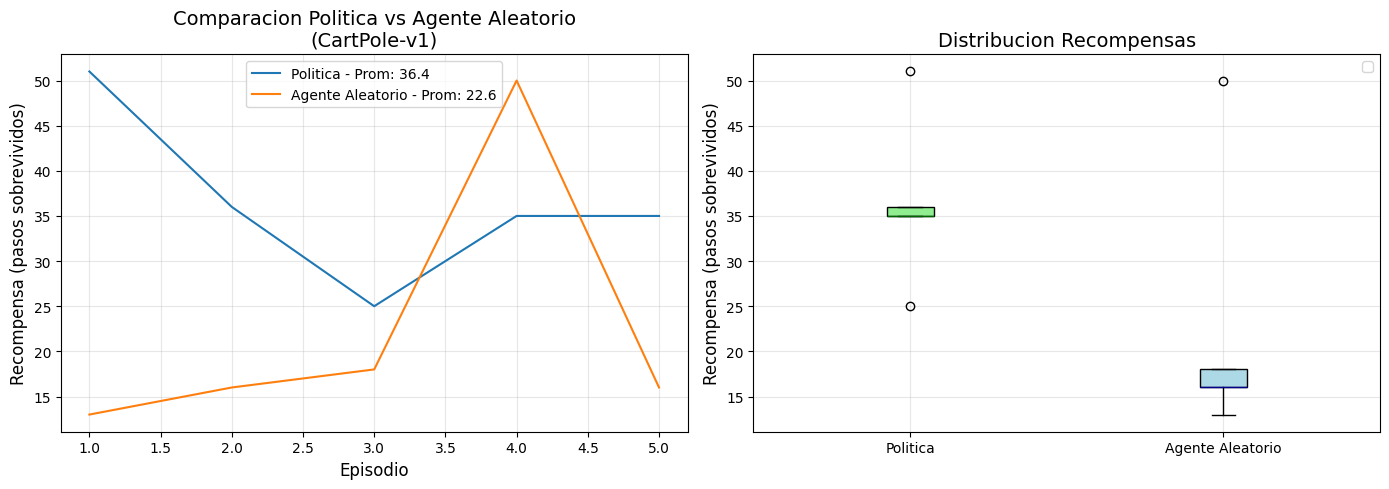

In [ ]:
#comparacion politica vs aleatorio
pro_politica = np.mean(recompensas_politica)
std_politica = np.std(recompensas_politica)

pro_aleatorio = np.mean(rewards_aleatorio_5)
std_aleatorio = np.std(rewards_aleatorio_5)

print(f"\n{'Metrica':<25} {'Politica (Angulo)':<25} {'Agente Aleatorio':<20}")
print("-"*70)
print(f"{'Recompensa promedio':<25} {pro_politica:<25.2f} {pro_aleatorio:<25.2f}")
print(f"{'Desviacion estandar':<25} {std_politica:<25.2f} {std_aleatorio:<25.2f}")
print(f"{'Pasos promedio':<25} {np.mean(pasos_politica):<25.2f} {np.mean(steps_aleatorio_5):<25.2f}")
print(f"{'Recompensa max':<25} {max(recompensas_politica):<25} {max(rewards_aleatorio_5):<25}")
print(f"{'Recompensa min':<25} {min(recompensas_politica):<25} {min(rewards_aleatorio_5):<25}")

mejora = ((pro_politica - pro_aleatorio) / pro_aleatorio) * 100
print(f"\n  - Mejora Politica vs Agente: {mejora:.2f}%")

if pro_politica > pro_aleatorio:
    print(f"  (Promedio: {pro_politica:.1f} vs {pro_aleatorio:.1f} pasos)")
else:
    print(f"  La politica no es mejor que el agente aleatorio")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#evol /ep
episodios = range(1, 6)
ax1.plot(episodios, recompensas_politica, markersize=10,
         label=f'Politica - Prom: {pro_politica:.1f}')
ax1.plot(episodios, rewards_aleatorio_5, markersize=10,
         label=f'Agente Aleatorio - Prom: {pro_aleatorio:.1f}')
ax1.set_xlabel('Episodio', fontsize=12)
ax1.set_ylabel('Recompensa (pasos sobrevividos)', fontsize=12)
ax1.set_title('Comparacion Politica vs Agente Aleatorio\n(CartPole-v1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

#boxplot
datos = [recompensas_politica, rewards_aleatorio_5]
bp = ax2.boxplot(datos, labels=['Politica', 'Agente Aleatorio'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightblue')
bp['medians'][0].set_color('darkgreen')
bp['medians'][1].set_color('darkblue')
ax2.set_ylabel('Recompensa (pasos sobrevividos)', fontsize=12)
ax2.set_title('Distribucion Recompensas', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Discusion y Analsis

- **Diferencias en desempeño y su relacion con la naturaleza de cada entorno:** Los modelos se diferencian principalmente por el tipo de problema, siendo CartPole un problema de control continuo y FrozenLake uno de navegación por lo que uno depende más de la física y el otro de la planificación de sus movimientos. Otra diferencia es que el primero da recompensas por pasos mientras que el otro al final. Sus niveles de randomizador tambien difieron siendo casi inexistente a relativamente alto respetivamente.
El desempeño de cada modelo se relaciona con sus ntauralezas de la siguiente forma, en CartPole cada accion contribuye de forma incremental al equilibrio, al recibir la recompensa en cada paso la supervivencia es vuelve más accesible y no es que haya puntos donde hayan fallos enormes.
Por otro lado tenemos FrozenLake que falla porque necestia una secuencia especifica al ser navegación, las recompensas no sob abundantes por ser dadas al final y el hecho de que esta el parametro de resbaladez que afecta las decisiones.
- **Política Simple vs Agente Aleatorio**: La politica supera al agente aleatorio por lo que podemos confirmar que se corrige el desequlibrio al seguir la relga establecida y tenemos las ventajas de que no hay necesidad de exploracion ni entrenamiento. Sin embargo hay limitantes en cuanto a que la velocidad agnular podria no ser considerada al igual que la posicion del carro, por lo que podria mejorarse al hacer que el aprendizaje considere multiples variables de estado de forma simulatanea.

- **Exploración vs explotación**: Es necesario explorar ya que el entorno de este caso no es estacionario y asi es posbile adaptarse y encontrar la política optima, ya que la que se creó podría no ser la óptima en todos los escenarios.
- **Entorno más interesante**: CarPole se me hace el mas interesante por el espacio de observacion que tiene, ademas de que tiene un feedback bastatnte denso. Esto deja que se pueda usar algoritmos avanzados de RL en entornos un poco mas controlados.
